# Generic April Test-Case Visualization

This notebook analyzes the merged April run suite under `runs/gen_apr0826`.
It reads each run directory's real `config.yaml`, `summary.json`, and `val.json`, renders the grouped static figures inline, builds the combined interactive PBL/MSE figures, and exports one tabbed HTML page for the complete combos it finds.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
if (cwd / "runs").is_dir() and (cwd / "notebooks").is_dir():
    REPO_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "runs").is_dir():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not determine repo root from {cwd}")

NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import test_case_viz_utils as utils

NORMAL_RUN_ROOT = REPO_ROOT / "runs" / "gen_apr0826"
PERTURB_RUN_ROOT = REPO_ROOT / "runs" / "gen_apr1126_perturb"
EXPORT_PATH = REPO_ROOT / "notebooks" / "interactive_exports" / "gen_apr0826" / "index.html"

suite_entries = [
    {
        "label": "Normal",
        "suite_id": "normal",
        "run_root": NORMAL_RUN_ROOT,
    },
    {
        "label": "Branch Perturbation",
        "suite_id": "branch-perturbation",
        "run_root": PERTURB_RUN_ROOT,
    },
]

for entry in suite_entries:
    entry["suite_data"] = utils.load_run_suite(entry["run_root"], skip_incomplete_combos=True)

combined_y_axis_preset = utils.compute_multi_suite_y_axis_preset(
    [entry["suite_data"] for entry in suite_entries]
)

suite_overview_rows = []
for entry in suite_entries:
    suite_data = entry["suite_data"]
    suite_overview_rows.append(
        {
            "suite": entry["label"],
            "run_root": str(entry["run_root"]),
            "expected_seeds": ", ".join(str(seed) for seed in suite_data["expected_seeds"]),
            "grouped_test_cases": ", ".join(suite_data["col_labels"]),
            "visible_combo_tabs": len(suite_data["combo_order"]),
            "selected_runs": len(suite_data["audit_rows"]),
            "missing_or_skipped_groups": len(suite_data["skipped_items"]),
        }
    )

display(Markdown("## Combined Suite Summary"))
display(pd.DataFrame(suite_overview_rows))
display(Markdown(f"**Shared uniform y-scale preset:** `{combined_y_axis_preset}`"))


## Combined Suite Summary

,suite,run_root,expected_seeds,grouped_test_cases,visible_combo_tabs,selected_runs,missing_or_skipped_groups
0,Normal,/home/osanghi/pfdelta/runs/gen_apr0826,"42, 43, 44","case14, case30, case57, case118, case500",6,198,0
1,Branch Perturbation,/home/osanghi/pfdelta/runs/gen_apr1126_perturb,"42, 43, 44","case14, case30, case57, case118, case500",6,195,1


**Shared uniform y-scale preset:** `{'lower': 1e-12, 'upper': 28621.760132511205, 'epsilon': 1e-12, 'plotly_log_range': [-12.0, 4.456696337751227]}`

# Normal

**Run root:** `/home/osanghi/pfdelta/runs/gen_apr0826`

**Expected seeds:** `[42, 43, 44]`

**Grouped test cases:** `['case14', 'case30', 'case57', 'case118', 'case500']`

,tab_label,model_slug,loss_family,selection_metric_key,pbl_metric_key,mse_metric_key,num_records,available_groups,total_groups,available_train_case_rows,total_train_case_rows
0,canos - mse,canos,mse,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,33,11,11,11,11
1,canos - pbl,canos,pbl,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,33,11,11,11,11
2,graphconv - mse,graphconv,mse,MSELoss,PBL Mean,MSELoss,33,11,11,11,11
3,graphconv - pbl,graphconv,pbl,PBL Mean,PBL Mean,MSELoss,33,11,11,11,11
4,powerflownet - mse,powerflownet,mse,MSELoss,PBL Mean,MSELoss,33,11,11,11,11
5,powerflownet - pbl,powerflownet,pbl,PBL Mean,PBL Mean,MSELoss,33,11,11,11,11


## Normal | Selected Run Audit

,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,mse,task31,case118,42,189,canos_pf_mse + 0.1 * pf_constraint_violation,0.128377,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
1,canos,mse,task31,case118,43,35,canos_pf_mse + 0.1 * pf_constraint_violation,0.583512,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
2,canos,mse,task31,case118,44,163,canos_pf_mse + 0.1 * pf_constraint_violation,0.193066,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
3,canos,mse,task31,case14,42,123,canos_pf_mse + 0.1 * pf_constraint_violation,0.002737,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
4,canos,mse,task31,case14,43,135,canos_pf_mse + 0.1 * pf_constraint_violation,0.002677,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
...,...,...,...,...,...,...,...,...,...,...
193,powerflownet,pbl,task34,case30_57_500,43,115,PBL Mean,0.112754,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
194,powerflownet,pbl,task34,case30_57_500,44,131,PBL Mean,0.120198,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
195,powerflownet,pbl,task34,case57_118_500,42,143,PBL Mean,0.118816,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
196,powerflownet,pbl,task34,case57_118_500,43,145,PBL Mean,0.111762,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...


## Normal | canos - pbl

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,pbl,task31,case118,42,193,canos_pf_mse + 0.1 * pf_constraint_violation,5.949637,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
1,canos,pbl,task31,case118,43,199,canos_pf_mse + 0.1 * pf_constraint_violation,5.646889,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
2,canos,pbl,task31,case118,44,1,canos_pf_mse + 0.1 * pf_constraint_violation,88.398222,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
3,canos,pbl,task31,case14,42,127,canos_pf_mse + 0.1 * pf_constraint_violation,0.007582,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
4,canos,pbl,task31,case14,43,137,canos_pf_mse + 0.1 * pf_constraint_violation,0.007349,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
5,canos,pbl,task31,case14,44,131,canos_pf_mse + 0.1 * pf_constraint_violation,0.007711,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
6,canos,pbl,task31,case30,42,157,canos_pf_mse + 0.1 * pf_constraint_violation,0.025133,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
7,canos,pbl,task31,case30,43,163,canos_pf_mse + 0.1 * pf_constraint_violation,0.017299,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
8,canos,pbl,task31,case30,44,143,canos_pf_mse + 0.1 * pf_constraint_violation,0.021642,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
9,canos,pbl,task31,case500,42,109,canos_pf_mse + 0.1 * pf_constraint_violation,341.720880,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...


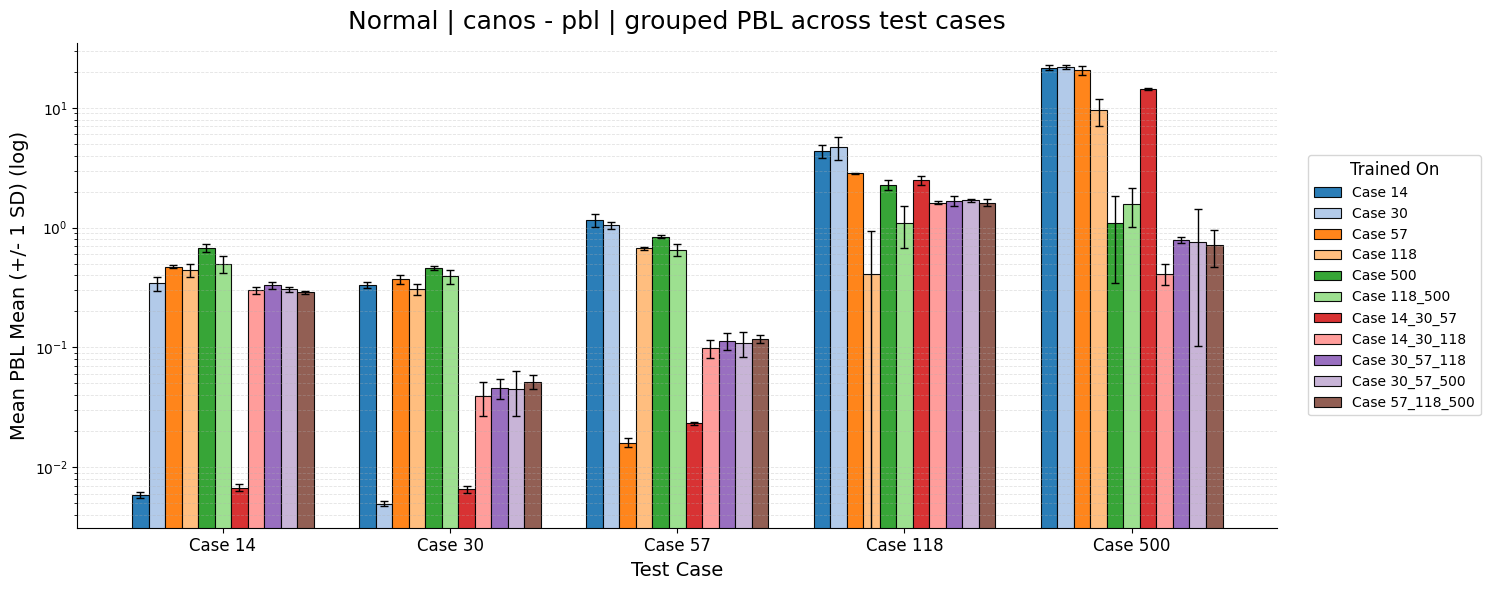

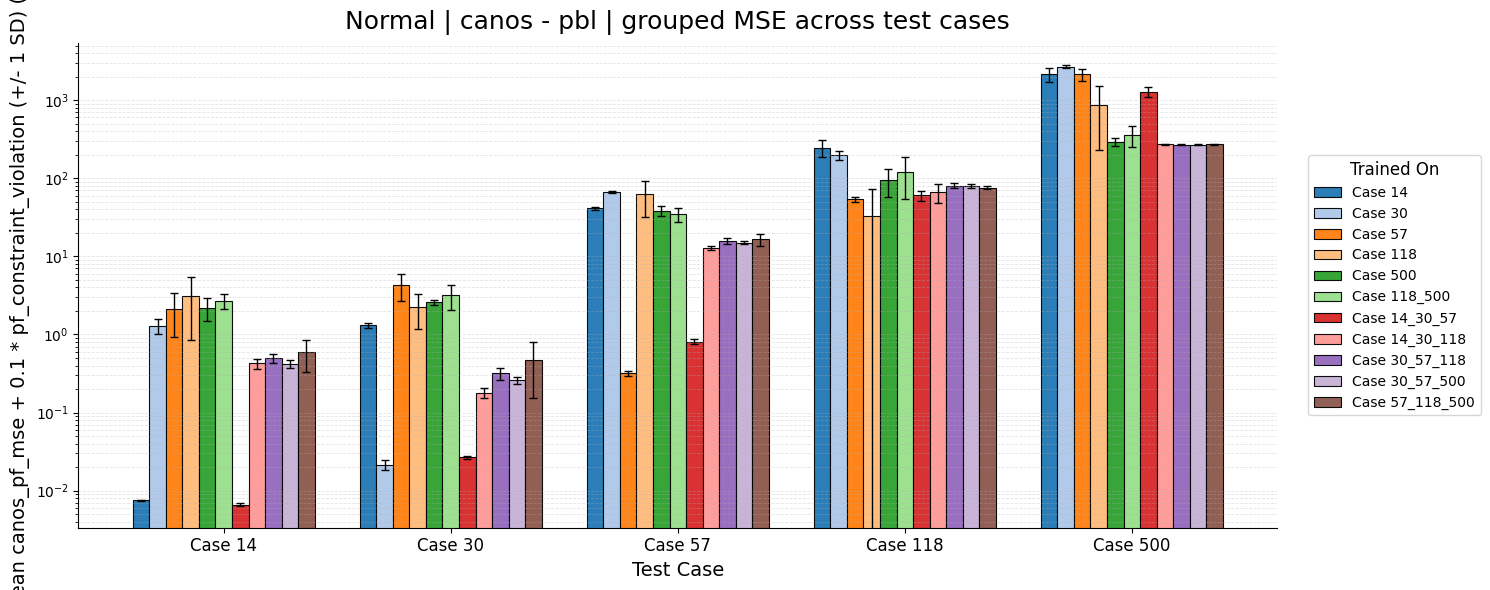

## Normal | canos - mse

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,mse,task31,case118,42,189,canos_pf_mse + 0.1 * pf_constraint_violation,0.128377,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
1,canos,mse,task31,case118,43,35,canos_pf_mse + 0.1 * pf_constraint_violation,0.583512,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
2,canos,mse,task31,case118,44,163,canos_pf_mse + 0.1 * pf_constraint_violation,0.193066,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
3,canos,mse,task31,case14,42,123,canos_pf_mse + 0.1 * pf_constraint_violation,0.002737,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
4,canos,mse,task31,case14,43,135,canos_pf_mse + 0.1 * pf_constraint_violation,0.002677,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
5,canos,mse,task31,case14,44,99,canos_pf_mse + 0.1 * pf_constraint_violation,0.003014,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
6,canos,mse,task31,case30,42,113,canos_pf_mse + 0.1 * pf_constraint_violation,0.006234,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
7,canos,mse,task31,case30,43,117,canos_pf_mse + 0.1 * pf_constraint_violation,0.003547,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
8,canos,mse,task31,case30,44,137,canos_pf_mse + 0.1 * pf_constraint_violation,0.003383,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
9,canos,mse,task31,case500,42,91,canos_pf_mse + 0.1 * pf_constraint_violation,5.161568,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...


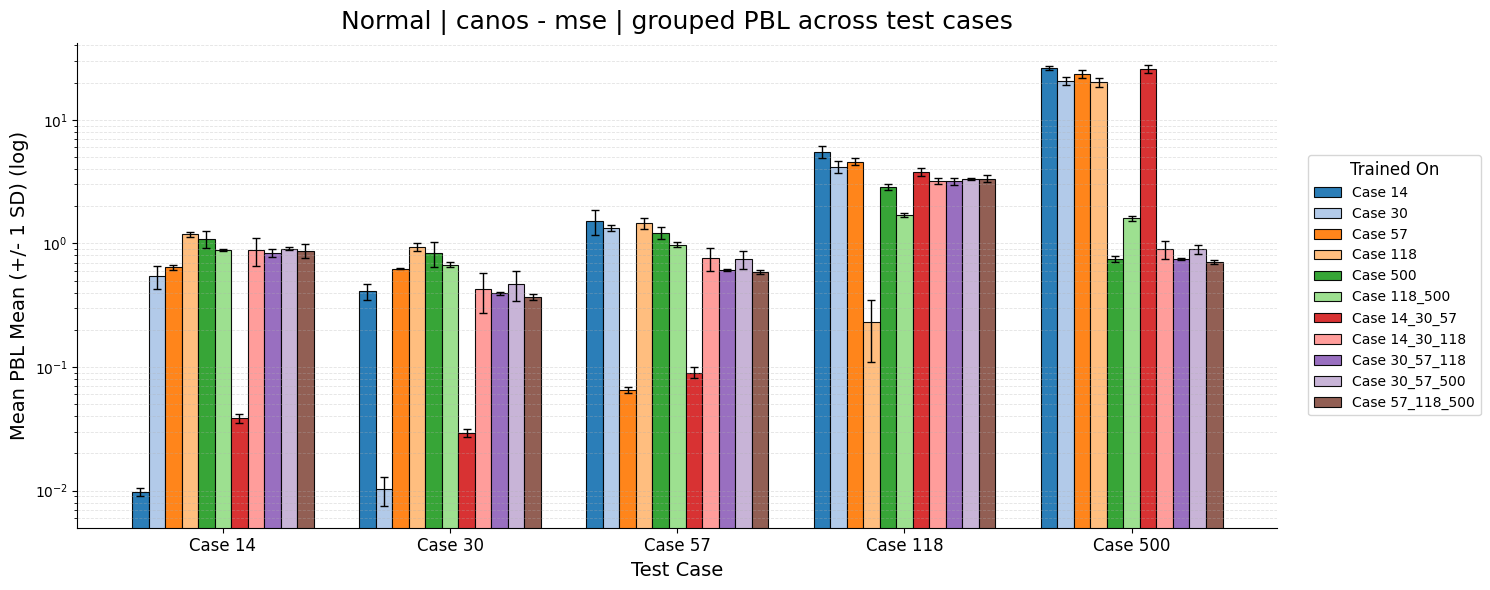

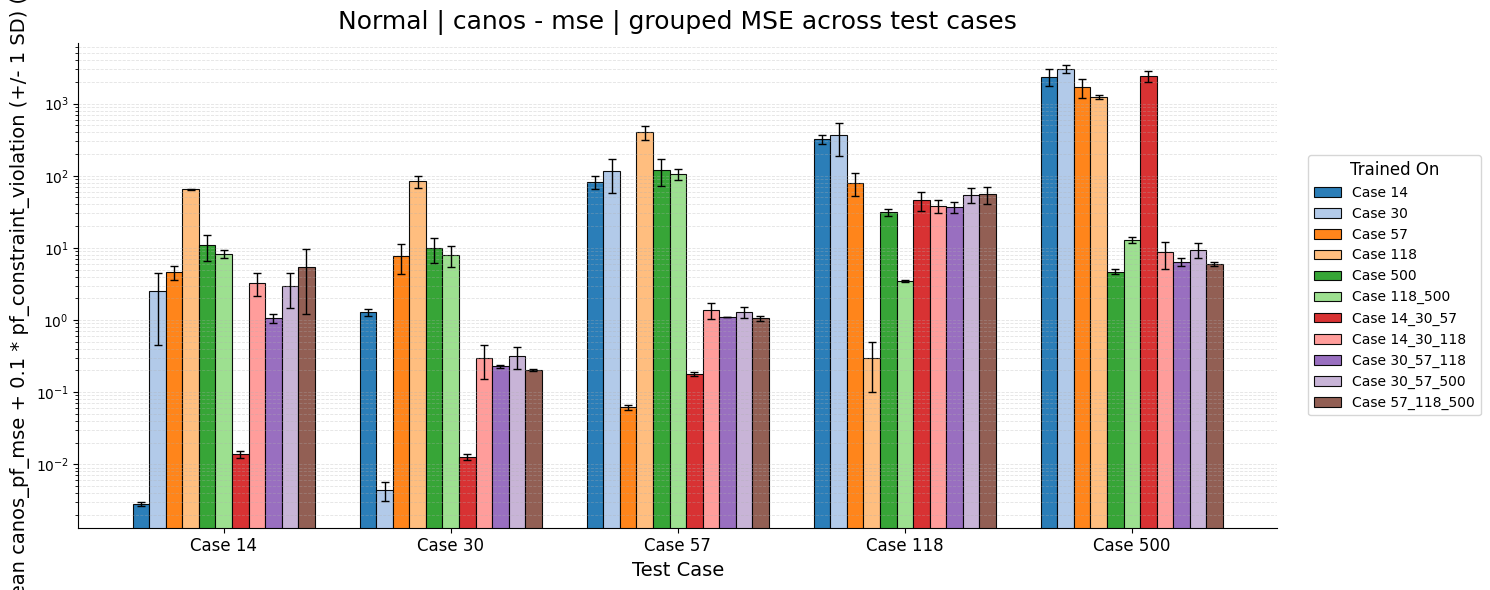

## Normal | graphconv - pbl

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,PBL Mean,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,graphconv,pbl,task31,case118,42,55,PBL Mean,0.269788,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
1,graphconv,pbl,task31,case118,43,91,PBL Mean,0.264912,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
2,graphconv,pbl,task31,case118,44,75,PBL Mean,0.266150,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
3,graphconv,pbl,task31,case14,42,89,PBL Mean,0.061898,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
4,graphconv,pbl,task31,case14,43,141,PBL Mean,0.059368,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
5,graphconv,pbl,task31,case14,44,81,PBL Mean,0.061714,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
6,graphconv,pbl,task31,case30,42,87,PBL Mean,0.043494,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
7,graphconv,pbl,task31,case30,43,65,PBL Mean,0.044052,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
8,graphconv,pbl,task31,case30,44,145,PBL Mean,0.042390,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
9,graphconv,pbl,task31,case500,42,33,PBL Mean,0.424751,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...


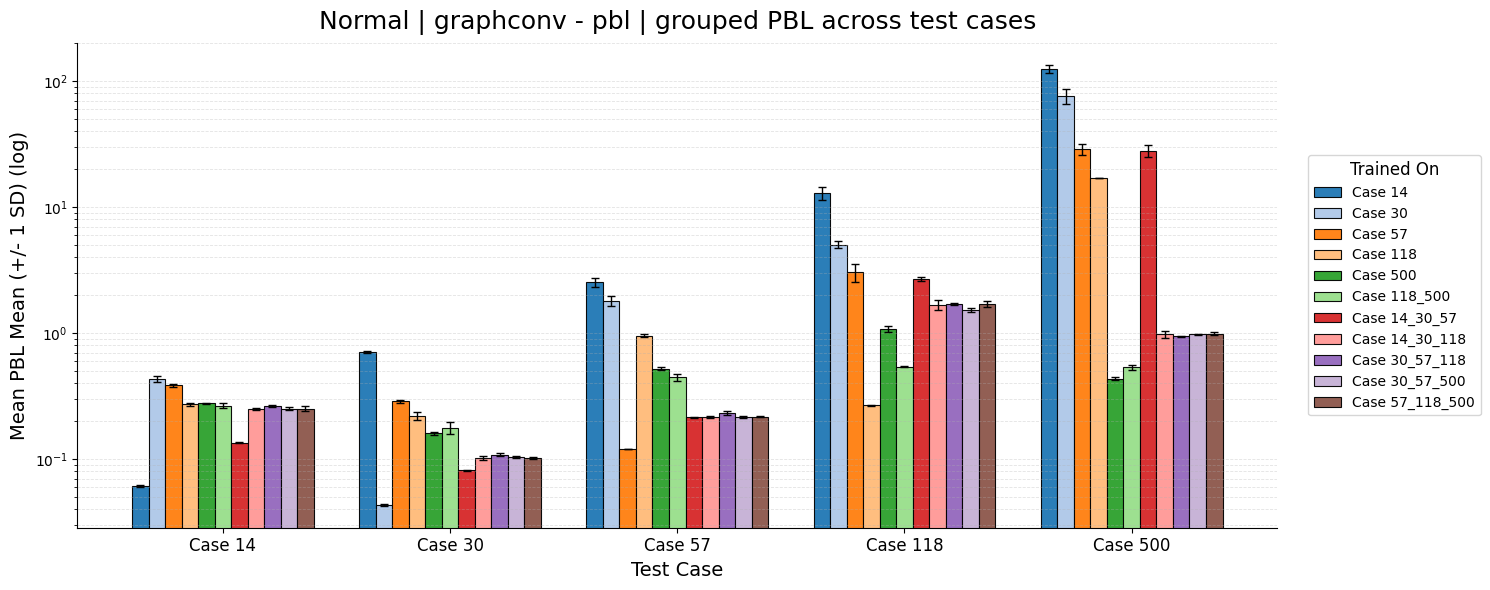

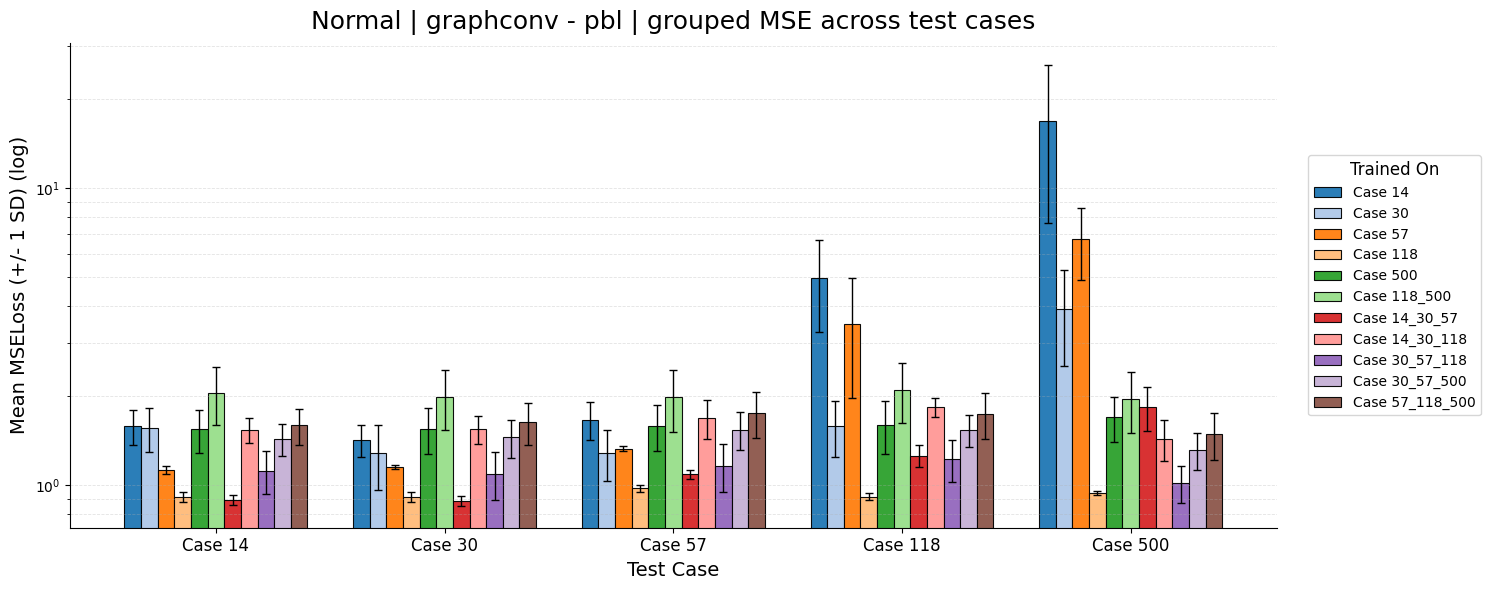

## Normal | graphconv - mse

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,MSELoss,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,graphconv,mse,task31,case118,42,97,MSELoss,0.066092,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
1,graphconv,mse,task31,case118,43,97,MSELoss,0.065324,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
2,graphconv,mse,task31,case118,44,67,MSELoss,0.068871,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
3,graphconv,mse,task31,case14,42,97,MSELoss,0.038813,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
4,graphconv,mse,task31,case14,43,131,MSELoss,0.034276,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
5,graphconv,mse,task31,case14,44,129,MSELoss,0.034436,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
6,graphconv,mse,task31,case30,42,91,MSELoss,0.035222,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
7,graphconv,mse,task31,case30,43,125,MSELoss,0.032571,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
8,graphconv,mse,task31,case30,44,127,MSELoss,0.032175,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
9,graphconv,mse,task31,case500,42,91,MSELoss,0.208545,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...


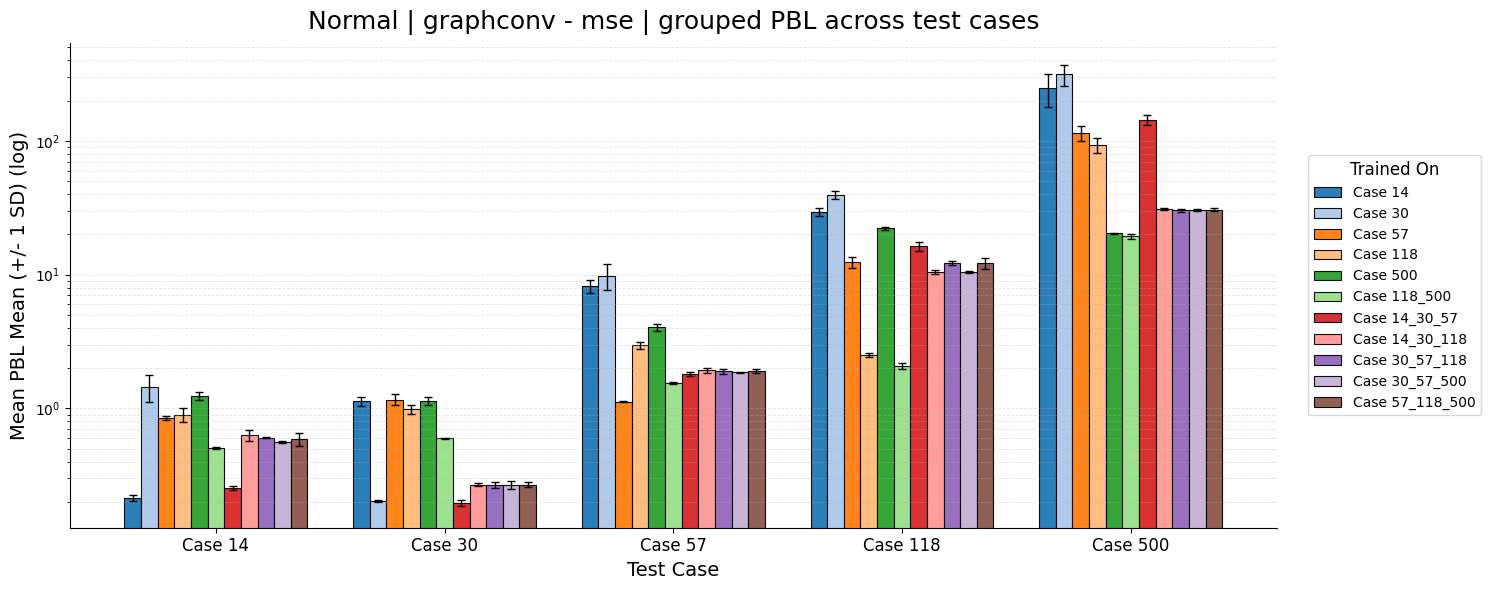

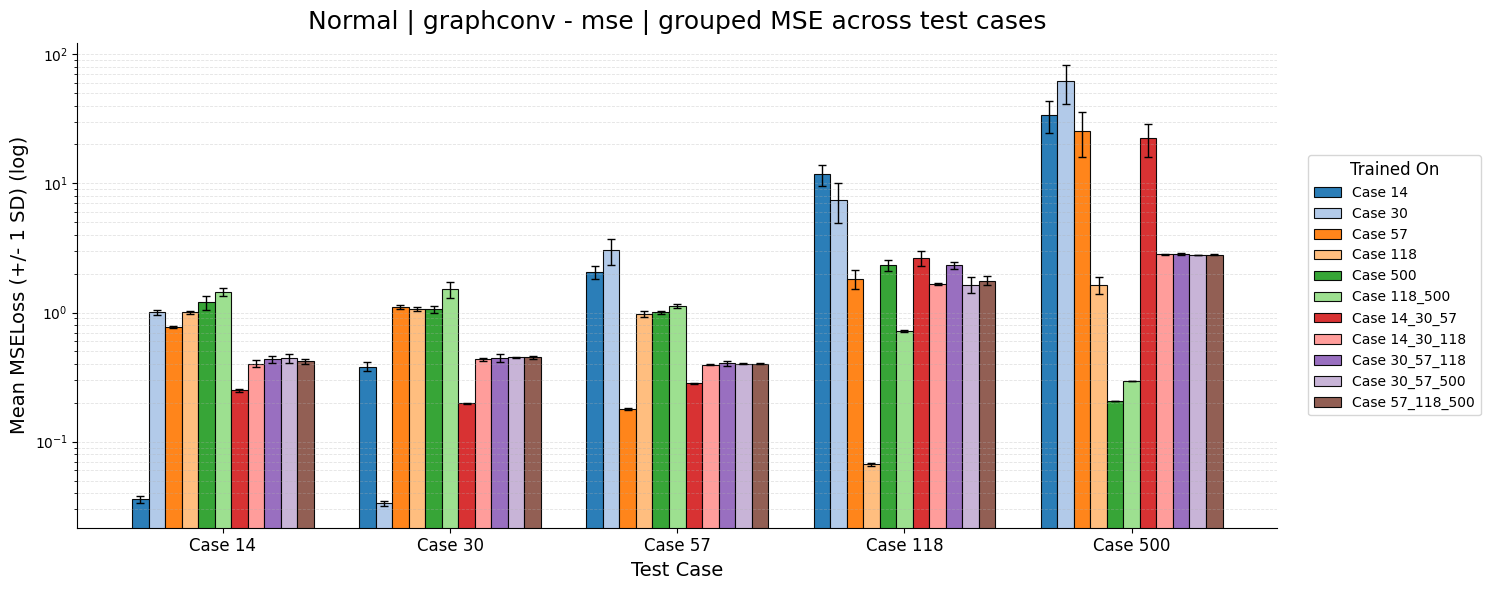

## Normal | powerflownet - pbl

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,PBL Mean,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,powerflownet,pbl,task31,case118,42,67,PBL Mean,0.090411,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
1,powerflownet,pbl,task31,case118,43,43,PBL Mean,0.098853,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
2,powerflownet,pbl,task31,case118,44,93,PBL Mean,0.092264,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
3,powerflownet,pbl,task31,case14,42,61,PBL Mean,0.016072,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
4,powerflownet,pbl,task31,case14,43,63,PBL Mean,0.015603,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
5,powerflownet,pbl,task31,case14,44,49,PBL Mean,0.020178,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
6,powerflownet,pbl,task31,case30,42,71,PBL Mean,0.012169,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
7,powerflownet,pbl,task31,case30,43,47,PBL Mean,0.013416,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
8,powerflownet,pbl,task31,case30,44,81,PBL Mean,0.013082,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...
9,powerflownet,pbl,task31,case500,42,41,PBL Mean,0.194394,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/pbl/tas...


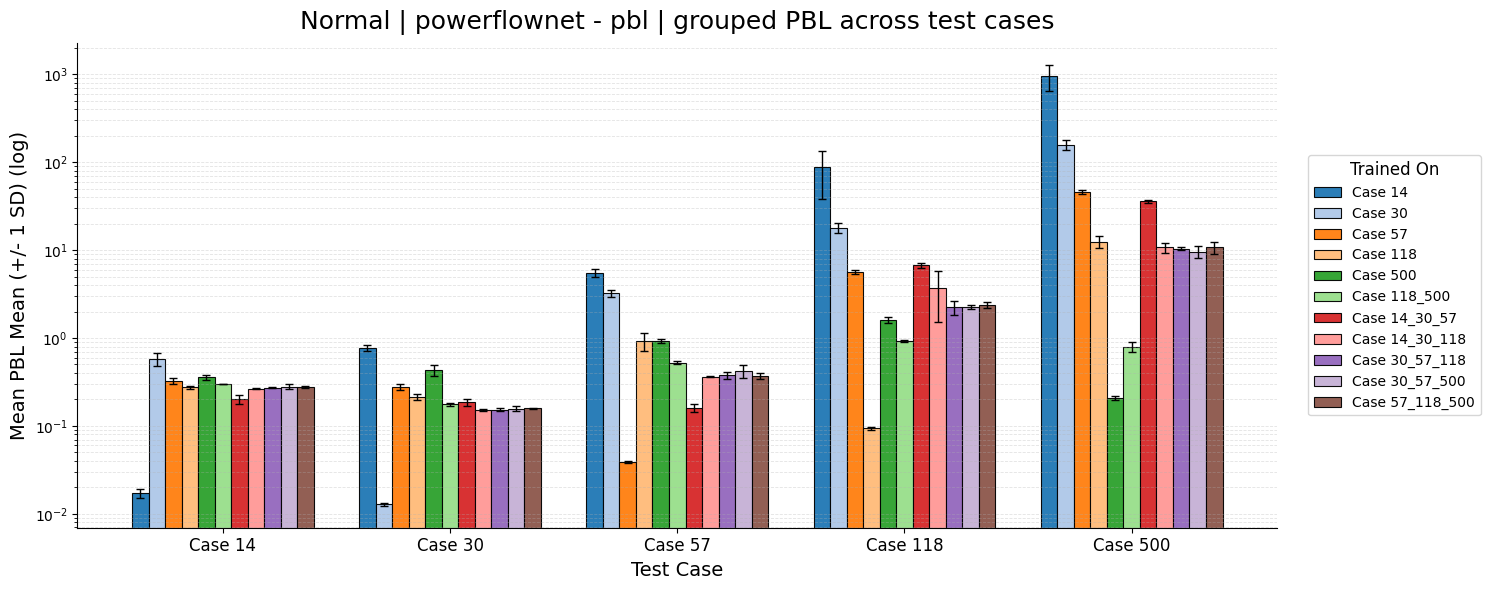

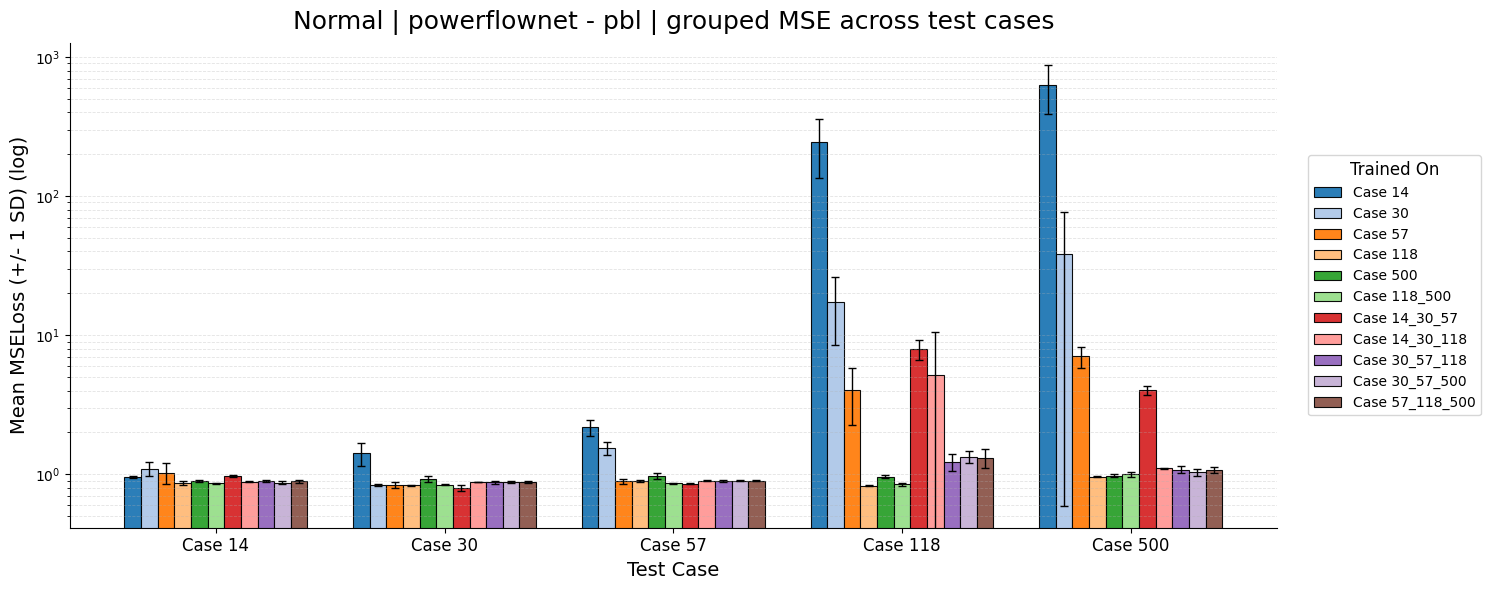

## Normal | powerflownet - mse

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,MSELoss,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,powerflownet,mse,task31,case118,42,119,MSELoss,0.003259,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
1,powerflownet,mse,task31,case118,43,95,MSELoss,0.003645,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
2,powerflownet,mse,task31,case118,44,107,MSELoss,0.003300,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
3,powerflownet,mse,task31,case14,42,55,MSELoss,0.002668,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
4,powerflownet,mse,task31,case14,43,61,MSELoss,0.002526,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
5,powerflownet,mse,task31,case14,44,49,MSELoss,0.003122,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
6,powerflownet,mse,task31,case30,42,97,MSELoss,0.002032,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
7,powerflownet,mse,task31,case30,43,63,MSELoss,0.002725,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
8,powerflownet,mse,task31,case30,44,103,MSELoss,0.002013,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...
9,powerflownet,mse,task31,case500,42,95,MSELoss,0.012959,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...,/home/osanghi/pfdelta/runs/gen_apr0826/mse/tas...


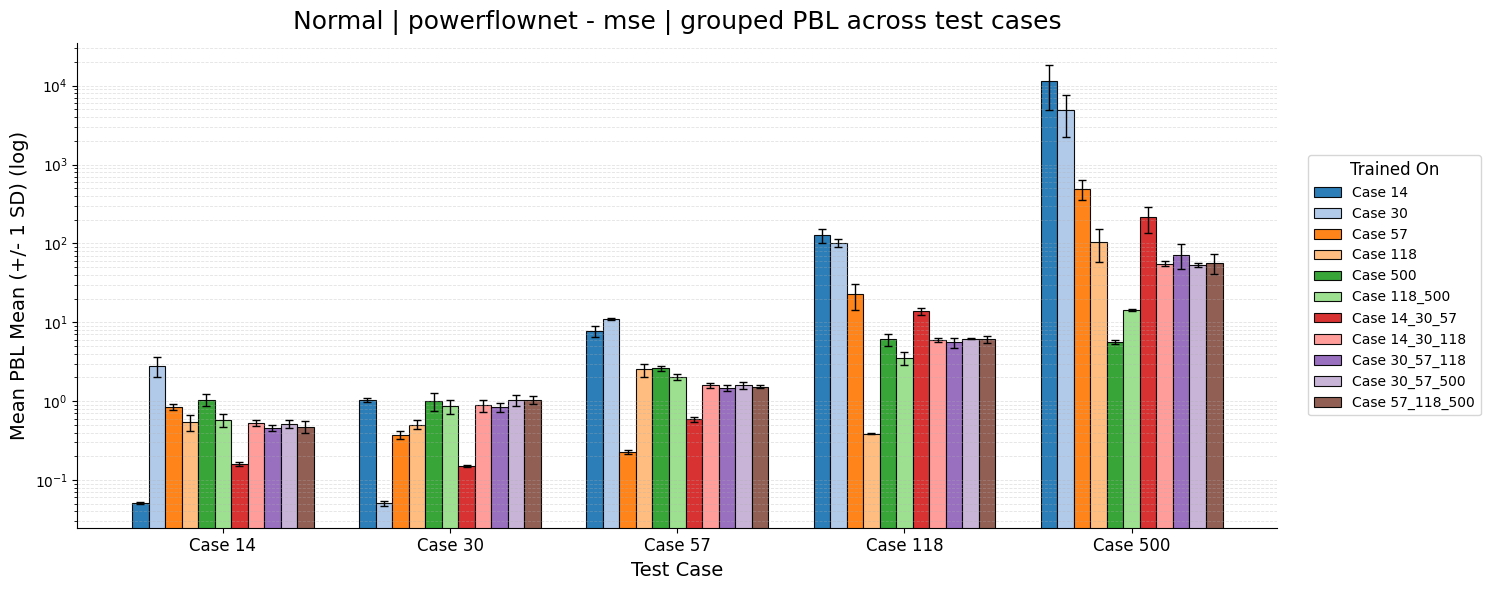

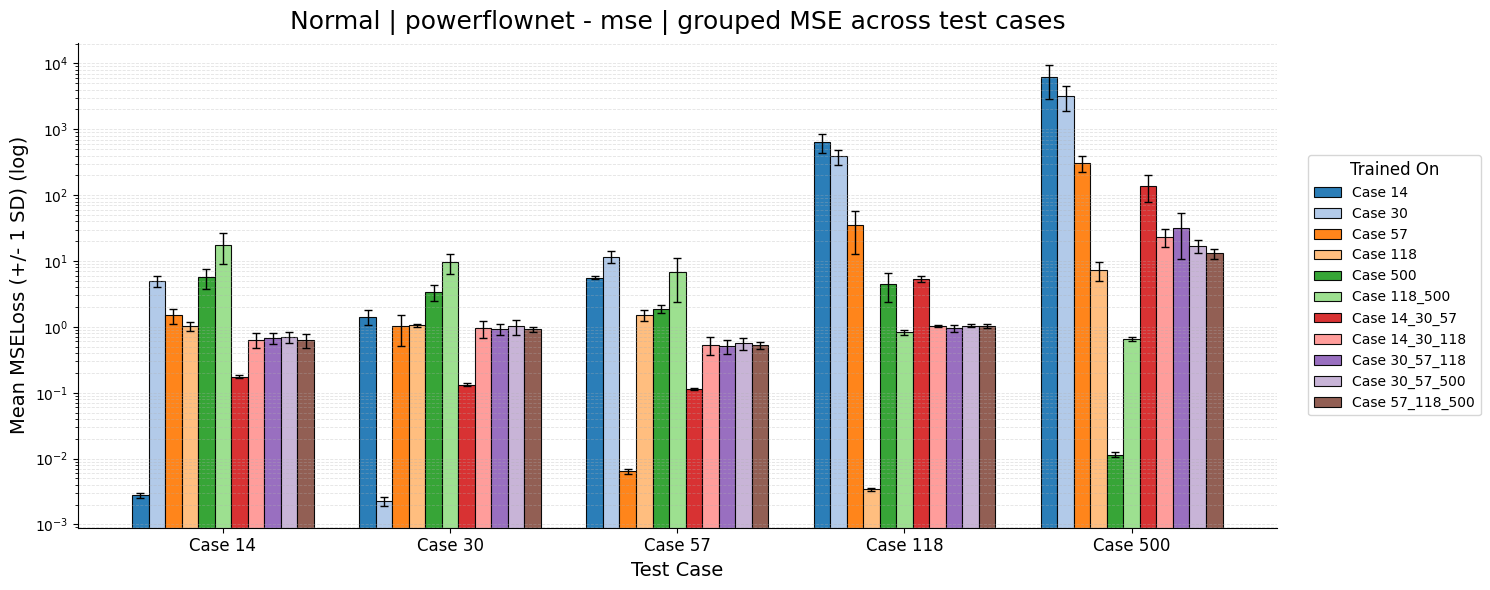

# Branch Perturbation

**Run root:** `/home/osanghi/pfdelta/runs/gen_apr1126_perturb`

**Expected seeds:** `[42, 43, 44]`

**Grouped test cases:** `['case14', 'case30', 'case57', 'case118', 'case500']`

,tab_label,model_slug,loss_family,selection_metric_key,pbl_metric_key,mse_metric_key,num_records,available_groups,total_groups,available_train_case_rows,total_train_case_rows
0,canos - mse,canos,mse,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,30,10,11,10,11
1,canos - pbl,canos,pbl,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,33,11,11,11,11
2,graphconv - mse,graphconv,mse,MSELoss,PBL Mean,MSELoss,33,11,11,11,11
3,graphconv - pbl,graphconv,pbl,PBL Mean,PBL Mean,MSELoss,33,11,11,11,11
4,powerflownet - mse,powerflownet,mse,MSELoss,PBL Mean,MSELoss,33,11,11,11,11
5,powerflownet - pbl,powerflownet,pbl,PBL Mean,PBL Mean,MSELoss,33,11,11,11,11


...

## Branch Perturbation | Selected Run Audit

,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,mse,task31,case118,42,197,canos_pf_mse + 0.1 * pf_constraint_violation,0.150480,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
1,canos,mse,task31,case118,43,185,canos_pf_mse + 0.1 * pf_constraint_violation,0.180967,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
2,canos,mse,task31,case118,44,193,canos_pf_mse + 0.1 * pf_constraint_violation,0.163749,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
3,canos,mse,task31,case14,42,197,canos_pf_mse + 0.1 * pf_constraint_violation,0.002195,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
4,canos,mse,task31,case14,43,109,canos_pf_mse + 0.1 * pf_constraint_violation,0.003280,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
...,...,...,...,...,...,...,...,...,...,...
190,powerflownet,pbl,task34,case30_57_500,43,117,PBL Mean,0.118765,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
191,powerflownet,pbl,task34,case30_57_500,44,143,PBL Mean,0.115676,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
192,powerflownet,pbl,task34,case57_118_500,42,79,PBL Mean,0.122446,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
193,powerflownet,pbl,task34,case57_118_500,43,79,PBL Mean,0.125654,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...


## Branch Perturbation | canos - pbl

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,pbl,task31,case118,42,187,canos_pf_mse + 0.1 * pf_constraint_violation,5.978919,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
1,canos,pbl,task31,case118,43,199,canos_pf_mse + 0.1 * pf_constraint_violation,5.627761,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
2,canos,pbl,task31,case118,44,151,canos_pf_mse + 0.1 * pf_constraint_violation,7.487861,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
3,canos,pbl,task31,case14,42,127,canos_pf_mse + 0.1 * pf_constraint_violation,0.007721,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
4,canos,pbl,task31,case14,43,141,canos_pf_mse + 0.1 * pf_constraint_violation,0.006921,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
5,canos,pbl,task31,case14,44,179,canos_pf_mse + 0.1 * pf_constraint_violation,0.005651,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
6,canos,pbl,task31,case30,42,187,canos_pf_mse + 0.1 * pf_constraint_violation,0.018472,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
7,canos,pbl,task31,case30,43,157,canos_pf_mse + 0.1 * pf_constraint_violation,0.048497,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
8,canos,pbl,task31,case30,44,101,canos_pf_mse + 0.1 * pf_constraint_violation,0.042191,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
9,canos,pbl,task31,case500,42,89,canos_pf_mse + 0.1 * pf_constraint_violation,369.927326,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...


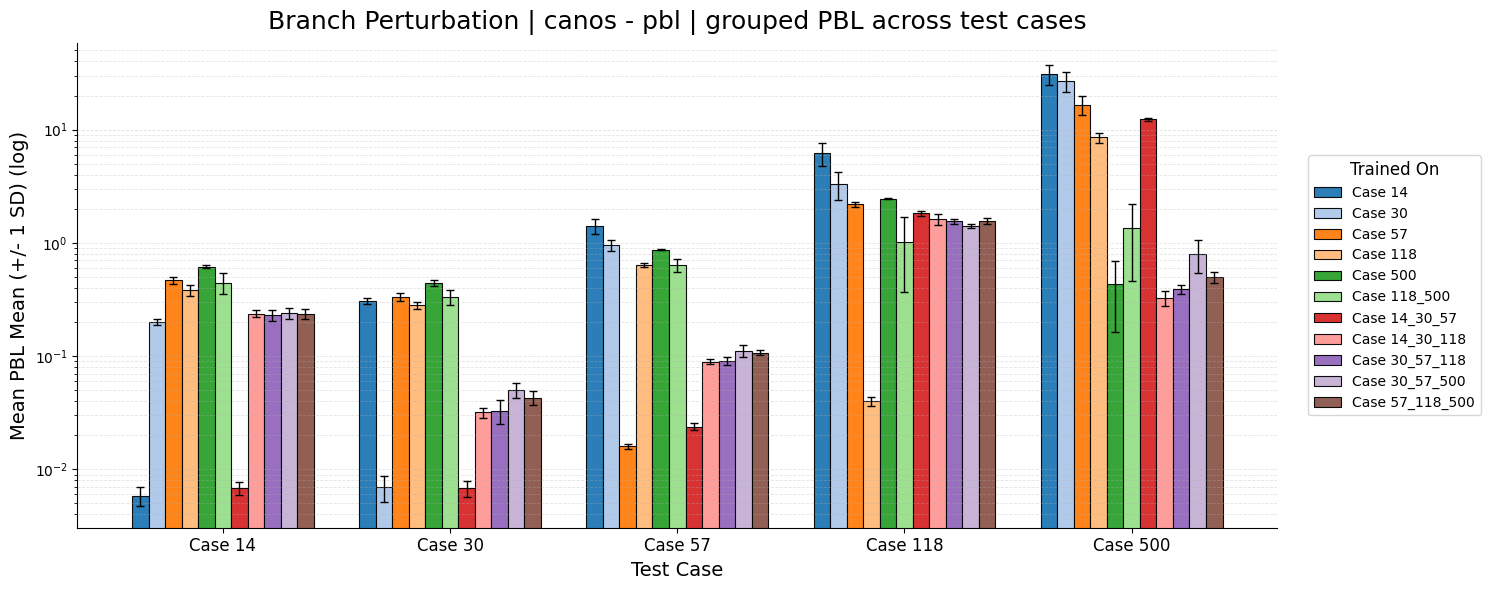

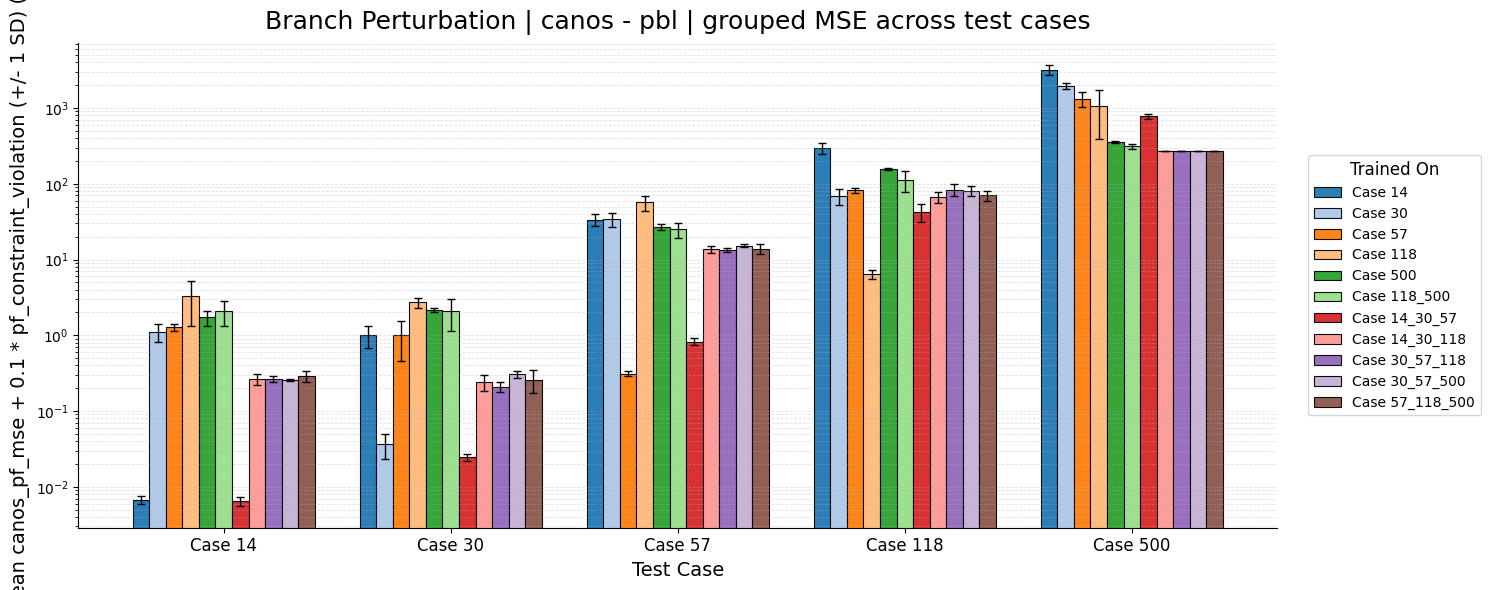

## Branch Perturbation | canos - mse

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,10,11,10,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,canos,mse,task31,case118,42,197,canos_pf_mse + 0.1 * pf_constraint_violation,0.150480,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
1,canos,mse,task31,case118,43,185,canos_pf_mse + 0.1 * pf_constraint_violation,0.180967,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
2,canos,mse,task31,case118,44,193,canos_pf_mse + 0.1 * pf_constraint_violation,0.163749,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
3,canos,mse,task31,case14,42,197,canos_pf_mse + 0.1 * pf_constraint_violation,0.002195,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
4,canos,mse,task31,case14,43,109,canos_pf_mse + 0.1 * pf_constraint_violation,0.003280,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
5,canos,mse,task31,case14,44,163,canos_pf_mse + 0.1 * pf_constraint_violation,0.002540,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
6,canos,mse,task31,case30,42,17,canos_pf_mse + 0.1 * pf_constraint_violation,0.047898,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
7,canos,mse,task31,case30,43,25,canos_pf_mse + 0.1 * pf_constraint_violation,0.041567,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
8,canos,mse,task31,case30,44,165,canos_pf_mse + 0.1 * pf_constraint_violation,0.003436,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
9,canos,mse,task31,case57,42,15,canos_pf_mse + 0.1 * pf_constraint_violation,0.873686,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...


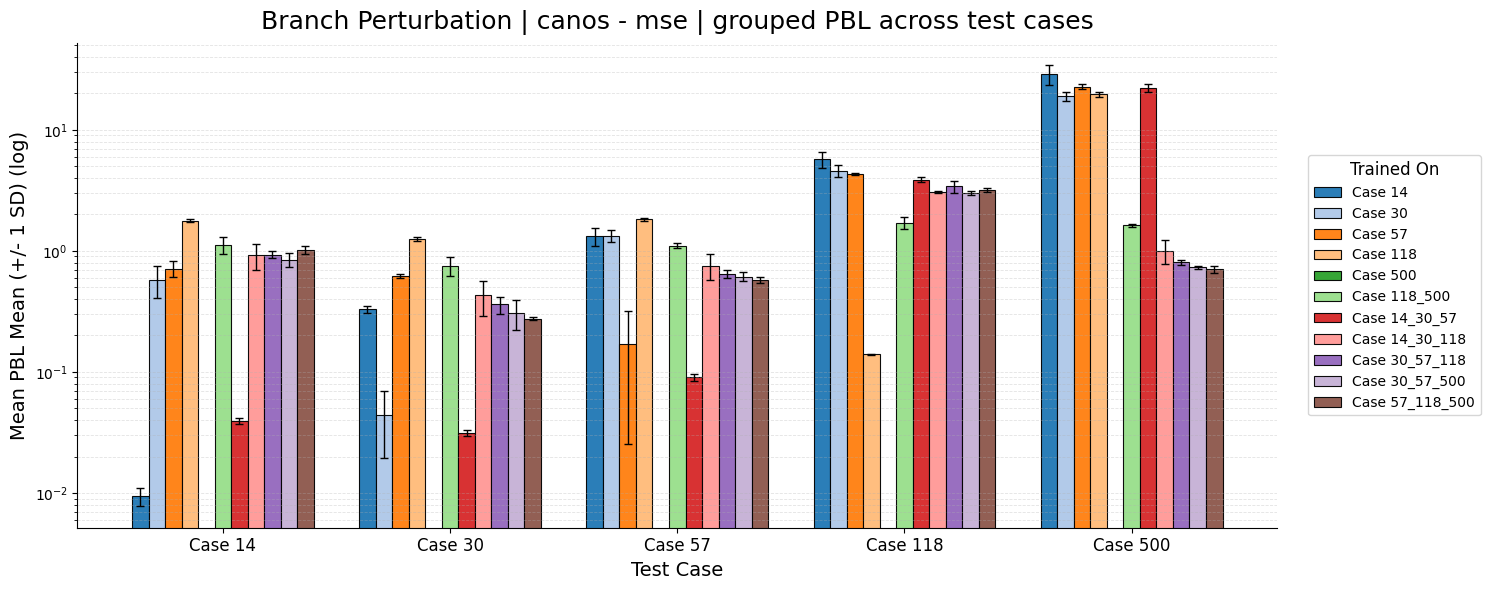

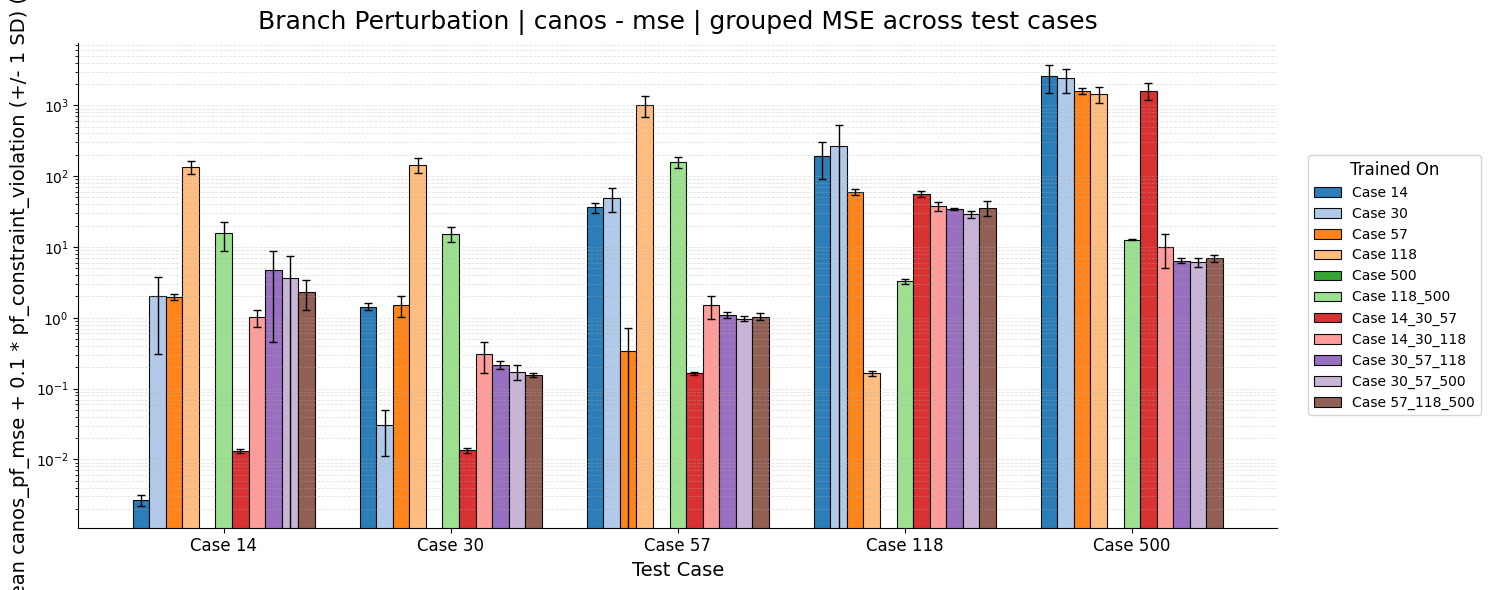

## Branch Perturbation | graphconv - pbl

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,PBL Mean,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,graphconv,pbl,task31,case118,42,85,PBL Mean,0.264690,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
1,graphconv,pbl,task31,case118,43,115,PBL Mean,0.263153,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
2,graphconv,pbl,task31,case118,44,23,PBL Mean,0.281442,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
3,graphconv,pbl,task31,case14,42,123,PBL Mean,0.060871,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
4,graphconv,pbl,task31,case14,43,97,PBL Mean,0.062443,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
5,graphconv,pbl,task31,case14,44,71,PBL Mean,0.063034,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
6,graphconv,pbl,task31,case30,42,137,PBL Mean,0.042829,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
7,graphconv,pbl,task31,case30,43,99,PBL Mean,0.043261,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
8,graphconv,pbl,task31,case30,44,43,PBL Mean,0.045132,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
9,graphconv,pbl,task31,case500,42,41,PBL Mean,0.410538,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...


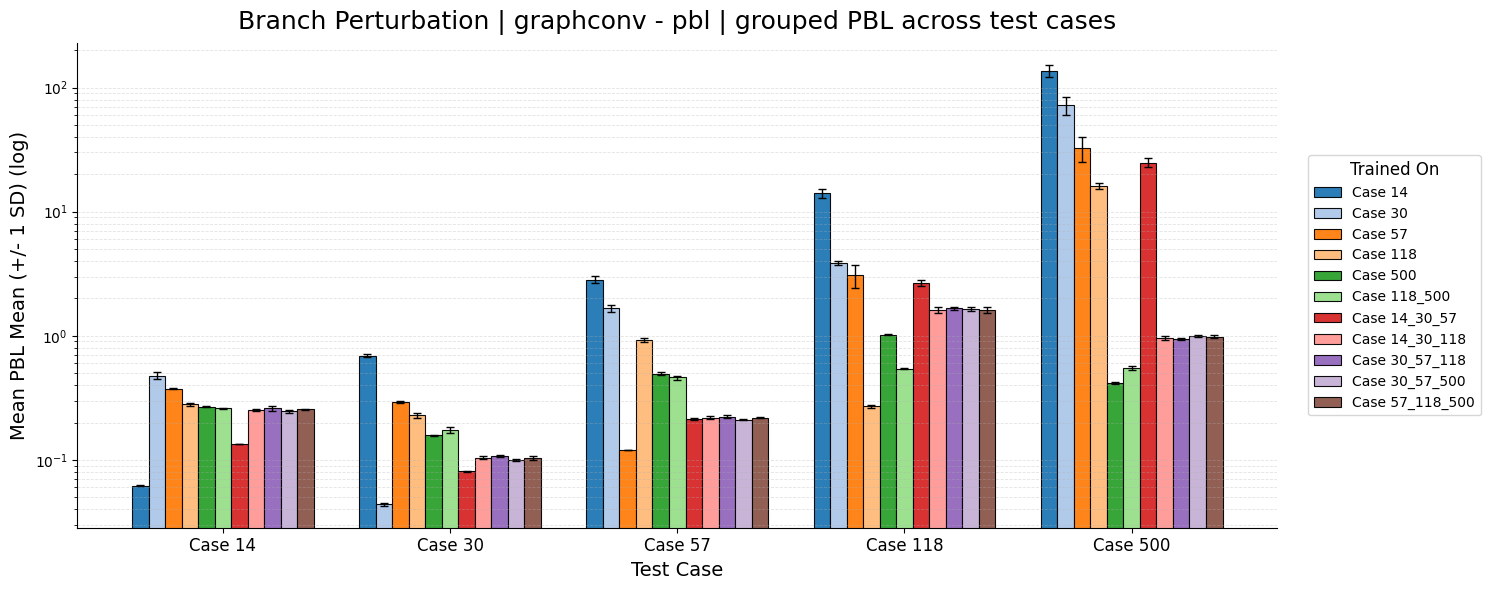

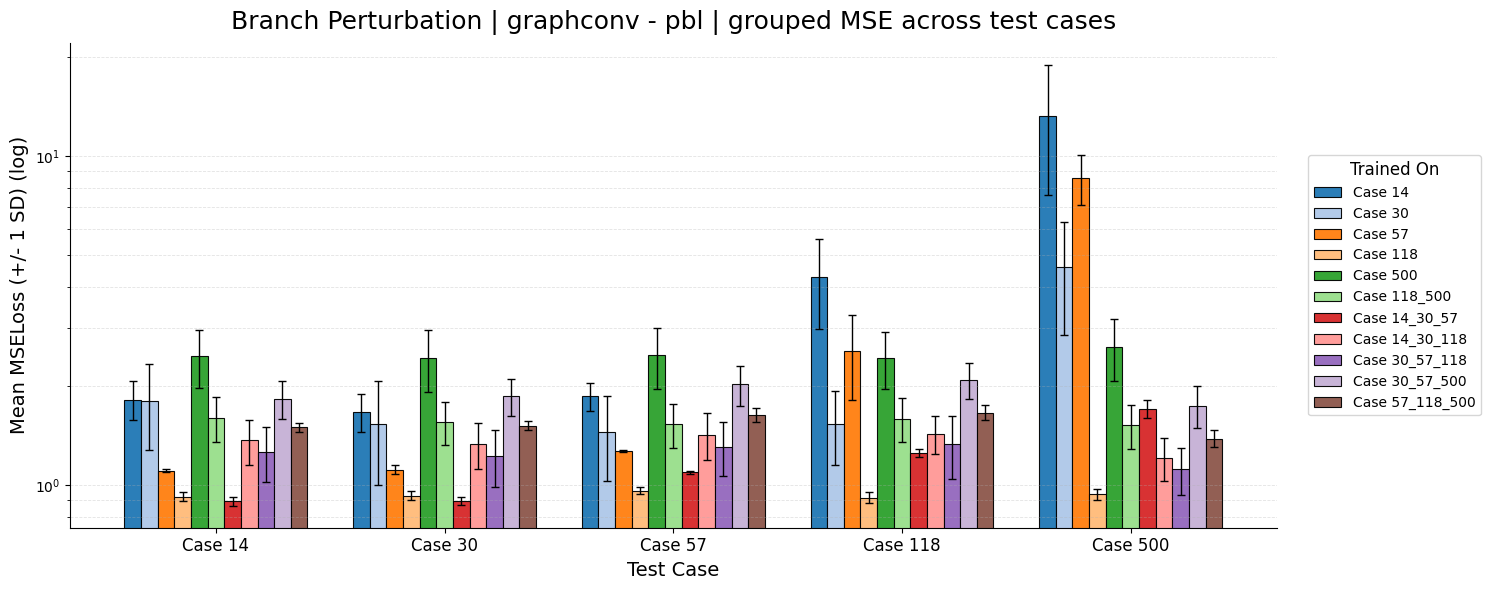

## Branch Perturbation | graphconv - mse

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,MSELoss,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,graphconv,mse,task31,case118,42,147,MSELoss,0.062256,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
1,graphconv,mse,task31,case118,43,147,MSELoss,0.062645,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
2,graphconv,mse,task31,case118,44,149,MSELoss,0.062218,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
3,graphconv,mse,task31,case14,42,133,MSELoss,0.033996,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
4,graphconv,mse,task31,case14,43,143,MSELoss,0.034111,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
5,graphconv,mse,task31,case14,44,129,MSELoss,0.035352,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
6,graphconv,mse,task31,case30,42,65,MSELoss,0.036210,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
7,graphconv,mse,task31,case30,43,113,MSELoss,0.033085,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
8,graphconv,mse,task31,case30,44,85,MSELoss,0.033853,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
9,graphconv,mse,task31,case500,42,71,MSELoss,0.209277,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...


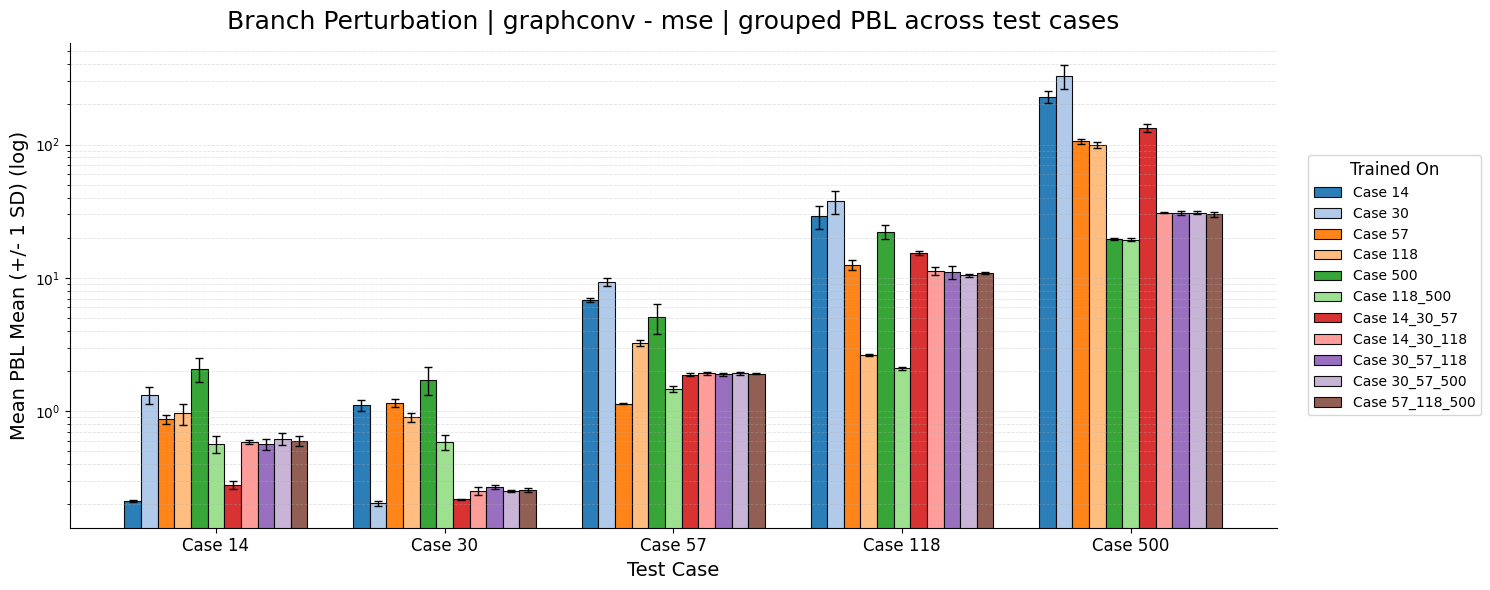

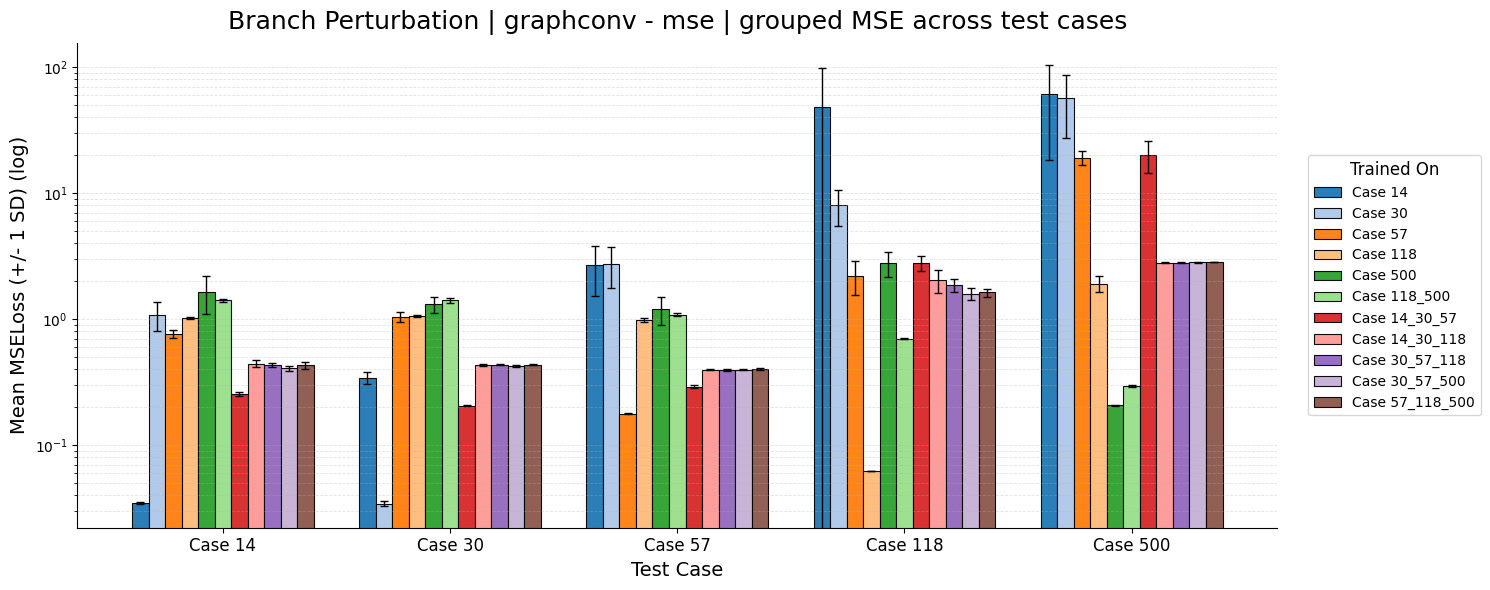

## Branch Perturbation | powerflownet - pbl

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,PBL Mean,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,powerflownet,pbl,task31,case118,42,73,PBL Mean,0.093049,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
1,powerflownet,pbl,task31,case118,43,65,PBL Mean,0.095559,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
2,powerflownet,pbl,task31,case118,44,77,PBL Mean,0.093673,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
3,powerflownet,pbl,task31,case14,42,45,PBL Mean,0.018743,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
4,powerflownet,pbl,task31,case14,43,63,PBL Mean,0.016932,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
5,powerflownet,pbl,task31,case14,44,49,PBL Mean,0.020158,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
6,powerflownet,pbl,task31,case30,42,67,PBL Mean,0.013745,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
7,powerflownet,pbl,task31,case30,43,55,PBL Mean,0.013125,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
8,powerflownet,pbl,task31,case30,44,83,PBL Mean,0.013521,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
9,powerflownet,pbl,task31,case500,42,33,PBL Mean,0.209899,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...


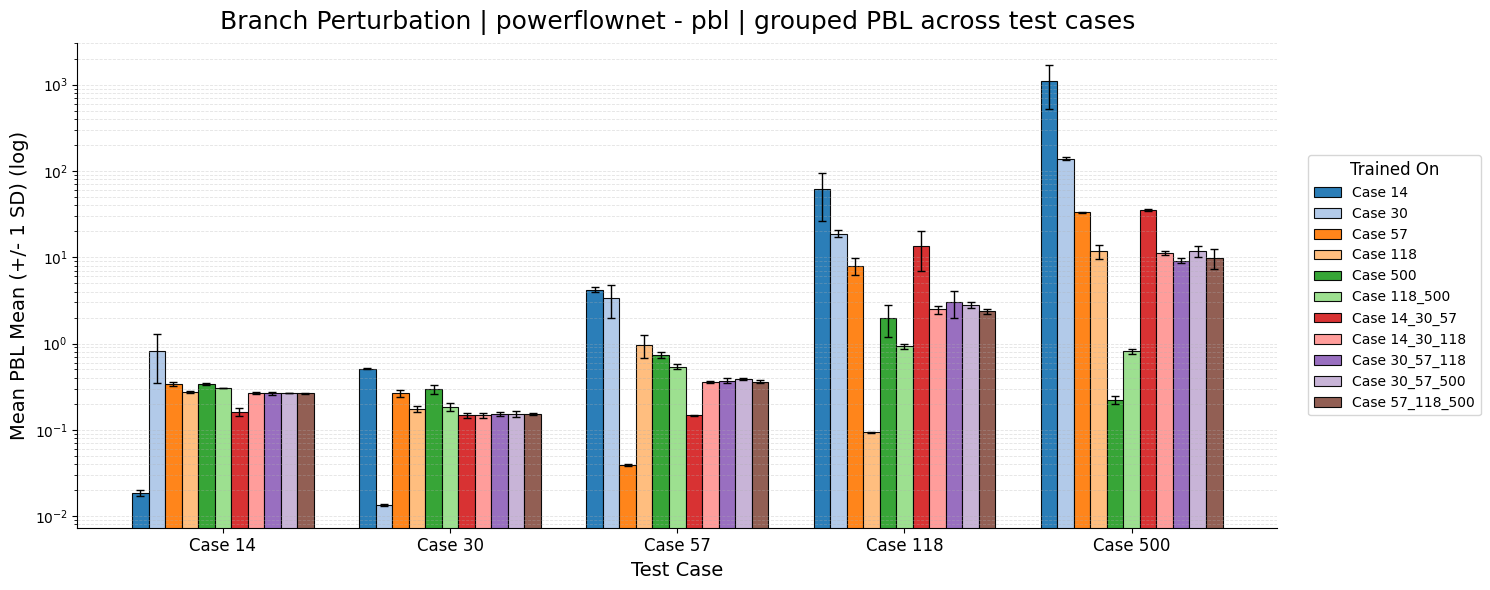

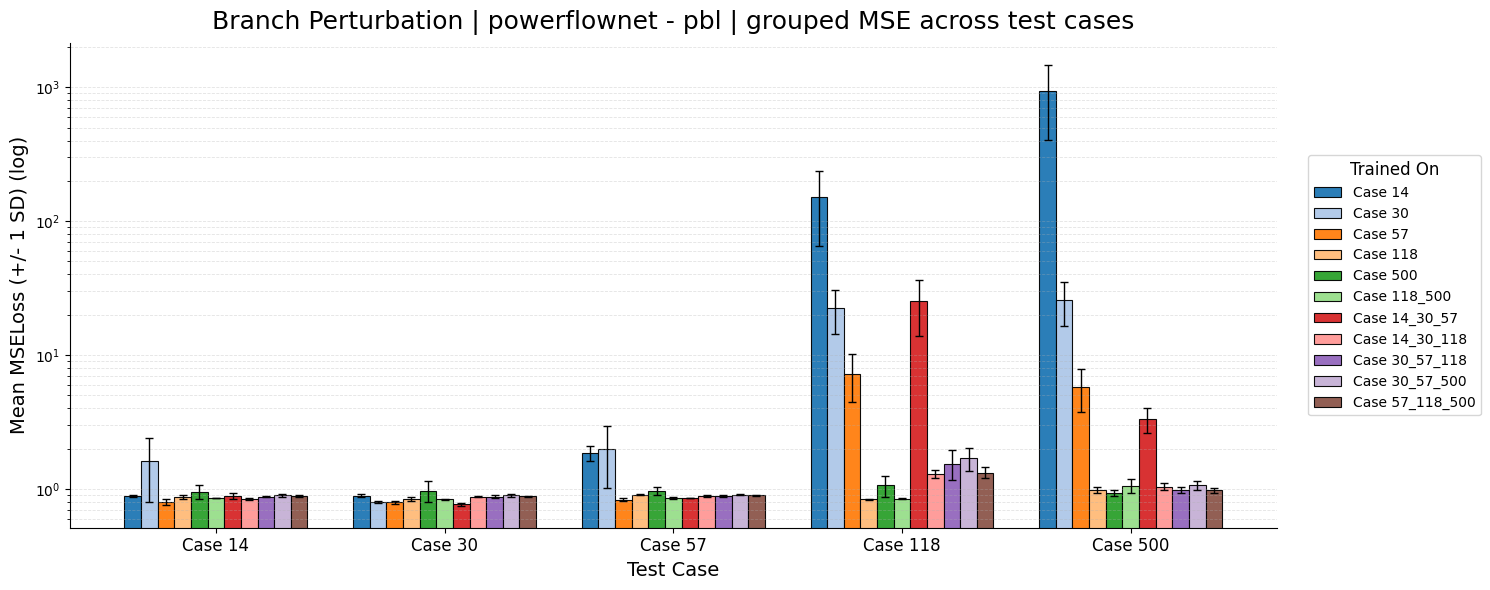

## Branch Perturbation | powerflownet - mse

,selection_metric,pbl_metric,mse_metric,available_groups,total_groups,available_train_case_rows,total_train_case_rows,test_case_columns,expected_seeds
0,MSELoss,PBL Mean,MSELoss,11,11,11,11,5,"42, 43, 44"


,model_slug,loss_family,task,train_case,seed,best_point,selection_metric_key,selection_metric_value,run_path,run_config_path
0,powerflownet,mse,task31,case118,42,81,MSELoss,0.003746,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
1,powerflownet,mse,task31,case118,43,91,MSELoss,0.003518,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
2,powerflownet,mse,task31,case118,44,121,MSELoss,0.003546,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
3,powerflownet,mse,task31,case14,42,53,MSELoss,0.002918,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
4,powerflownet,mse,task31,case14,43,35,MSELoss,0.003924,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
5,powerflownet,mse,task31,case14,44,49,MSELoss,0.002894,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
6,powerflownet,mse,task31,case30,42,93,MSELoss,0.002133,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
7,powerflownet,mse,task31,case30,43,71,MSELoss,0.002441,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
8,powerflownet,mse,task31,case30,44,81,MSELoss,0.002377,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...
9,powerflownet,mse,task31,case500,42,145,MSELoss,0.010409,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...,/home/osanghi/pfdelta/runs/gen_apr1126_perturb...


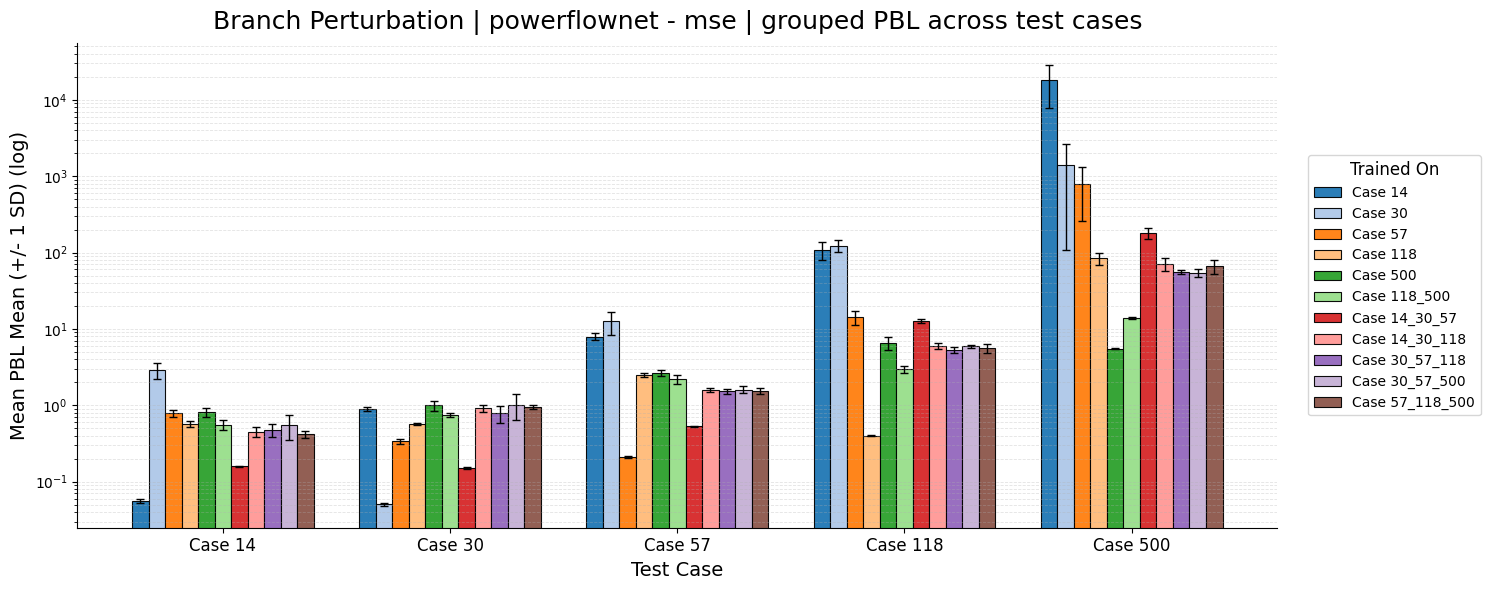

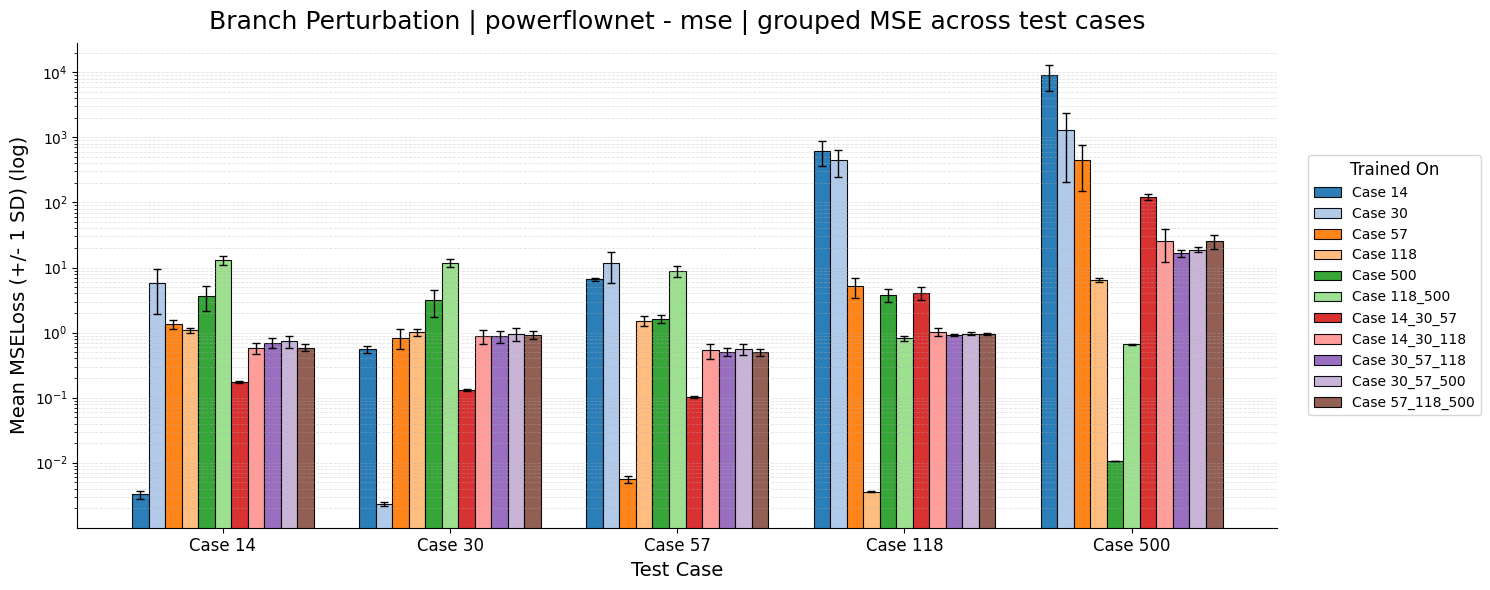

## Rendered Combo Summary

,suite,tab_label,default_visible,selection_metric,pbl_metric,mse_metric,available_groups,total_groups
0,Normal,canos - pbl,PBL,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,11
1,Normal,canos - mse,MSE,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,11
2,Normal,graphconv - pbl,PBL,PBL Mean,PBL Mean,MSELoss,11,11
3,Normal,graphconv - mse,MSE,MSELoss,PBL Mean,MSELoss,11,11
4,Normal,powerflownet - pbl,PBL,PBL Mean,PBL Mean,MSELoss,11,11
5,Normal,powerflownet - mse,MSE,MSELoss,PBL Mean,MSELoss,11,11
6,Branch Perturbation,canos - pbl,PBL,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,11,11
7,Branch Perturbation,canos - mse,MSE,canos_pf_mse + 0.1 * pf_constraint_violation,PBL Mean,canos_pf_mse + 0.1 * pf_constraint_violation,10,11
8,Branch Perturbation,graphconv - pbl,PBL,PBL Mean,PBL Mean,MSELoss,11,11
9,Branch Perturbation,graphconv - mse,MSE,MSELoss,PBL Mean,MSELoss,11,11


In [2]:
suite_specs = []
render_summary_rows = []

for entry in suite_entries:
    suite_label = entry["label"]
    suite_id = entry["suite_id"]
    run_root = entry["run_root"]
    suite_data = entry["suite_data"]

    combo_summary_df = pd.DataFrame(suite_data["combo_summary_rows"]).sort_values(
        ["model_slug", "loss_family"]
    ).reset_index(drop=True)
    audit_df = pd.DataFrame(suite_data["audit_rows"]).sort_values(
        ["model_slug", "loss_family", "task", "train_case", "seed"]
    ).reset_index(drop=True)
    skipped_df = pd.DataFrame(suite_data["skipped_items"]).reset_index(drop=True)

    display(Markdown(f"# {suite_label}"))
    display(Markdown(f"**Run root:** `{run_root}`"))
    display(Markdown(f"**Expected seeds:** `{suite_data['expected_seeds']}`"))
    display(Markdown(f"**Grouped test cases:** `{suite_data['col_labels']}`"))
    display(combo_summary_df)

    if not skipped_df.empty:
        display(Markdown(f"## {suite_label} | Missing Or Skipped Groups"))
        display(Markdown(
            "These entries explain which train-case groups were missing full 3-seed coverage or valid run artifacts, so those bar slots will render empty in the grouped plots."
        ))
        display(skipped_df)

    display(Markdown(f"## {suite_label} | Selected Run Audit"))
    display(audit_df)

    combo_tab_specs = []

    for combo_key in suite_data["combo_order"]:
        combo = suite_data["combos"][combo_key]
        display(Markdown(f"## {suite_label} | {combo['display_name']}"))

        combo_meta_df = pd.DataFrame(
            [
                {
                    "selection_metric": combo["selection_metric_key"],
                    "pbl_metric": combo["pbl_metric_key"],
                    "mse_metric": combo["mse_metric_key"],
                    "available_groups": combo["available_group_count"],
                    "total_groups": combo["total_group_count"],
                    "available_train_case_rows": combo["available_row_count"],
                    "total_train_case_rows": combo["total_row_count"],
                    "test_case_columns": len(combo["col_labels"]),
                    "expected_seeds": ", ".join(str(seed) for seed in combo["expected_seeds"]),
                }
            ]
        )
        display(combo_meta_df)

        combo_audit_df = pd.DataFrame(combo["audit_rows"]).sort_values(
            ["task", "train_case", "seed"]
        ).reset_index(drop=True)
        display(combo_audit_df)

        pbl_data = utils.build_metric_matrices(combo, combo["pbl_metric_key"])
        mse_data = utils.build_metric_matrices(combo, combo["mse_metric_key"])

        utils.plot_grouped_bar_chart(
            pbl_data["means"],
            pbl_data["stds"],
            pbl_data["row_labels"],
            pbl_data["col_labels"],
            pbl_data["metric_label"],
            f"{suite_label} | {combo['display_name']} | grouped PBL across test cases",
        )

        utils.plot_grouped_bar_chart(
            mse_data["means"],
            mse_data["stds"],
            mse_data["row_labels"],
            mse_data["col_labels"],
            mse_data["metric_label"],
            f"{suite_label} | {combo['display_name']} | grouped MSE across test cases",
        )

        default_visible = "PBL" if combo["loss_family"].lower() == "pbl" else "MSE"
        combined_figure = utils.plot_metric_toggle_chart(
            pbl_data,
            mse_data,
            title=f"{suite_label} | {combo['display_name']} | grouped PBL vs MSE across test cases",
            default_visible=default_visible,
        )

        combo_tab_specs.append(
            {
                "label": combo["display_name"],
                "tab_id": f"{combo['model_slug']}-{combo['loss_family']}",
                "figure": combined_figure,
                "metadata": [
                    ("Selection metric", combo["selection_metric_key"]),
                    ("PBL metric", combo["pbl_metric_key"]),
                    ("MSE metric", combo["mse_metric_key"]),
                    ("Available train-case rows", combo["available_row_count"]),
                    ("Total train-case rows", combo["total_row_count"]),
                    ("Available groups", combo["available_group_count"]),
                    ("Total groups", combo["total_group_count"]),
                    ("Expected seeds", ", ".join(str(seed) for seed in combo["expected_seeds"])),
                ],
            }
        )

        render_summary_rows.append(
            {
                "suite": suite_label,
                "tab_label": combo["display_name"],
                "default_visible": default_visible,
                "selection_metric": combo["selection_metric_key"],
                "pbl_metric": combo["pbl_metric_key"],
                "mse_metric": combo["mse_metric_key"],
                "available_groups": combo["available_group_count"],
                "total_groups": combo["total_group_count"],
            }
        )

    suite_specs.append(
        {
            "label": suite_label,
            "suite_id": suite_id,
            "metadata": [
                ("Run root", str(run_root)),
                ("Expected seeds", ", ".join(str(seed) for seed in suite_data["expected_seeds"])),
                ("Grouped test cases", ", ".join(suite_data["col_labels"])),
                ("Visible combo tabs", len(combo_tab_specs)),
                ("Suite row slots", len(suite_data["row_labels"])),
            ],
            "tab_specs": combo_tab_specs,
        }
    )

display(Markdown("## Rendered Combo Summary"))
display(pd.DataFrame(render_summary_rows))


In [3]:
written_path = utils.write_multi_suite_tabbed_interactive_export(
    suite_specs,
    EXPORT_PATH,
    page_title="April interactive test-case charts",
    y_axis_preset=combined_y_axis_preset,
)

export_df = pd.DataFrame(
    [
        {
            "export_file": "index.html",
            "repo_relative_path": str(Path(written_path).resolve().relative_to(REPO_ROOT)),
            "absolute_path": str(Path(written_path).resolve()),
            "num_suites": len(suite_specs),
            "num_combo_tabs": sum(len(spec["tab_specs"]) for spec in suite_specs),
        }
    ]
)

display(Markdown("## Interactive Export"))
display(export_df)


## Interactive Export

,export_file,repo_relative_path,absolute_path,num_suites,num_combo_tabs
0,index.html,notebooks/interactive_exports/gen_apr0826/inde...,/home/osanghi/pfdelta/notebooks/interactive_ex...,2,12


## Re-run Export

You can re-execute this notebook and refresh the exported HTML with:

```bash
bash scripts/interactive_exports/generate_interactive_exports.sh
```
